In [1]:
'''
UMAP Visualization Script for Pancreas Dataset
This script decodes the generated latent embedding into gene expression matrix 
and creates UMAP visualizations comparing real vs generated cells
'''

'\nUMAP Visualization Script for Pancreas Dataset\nThis script decodes the generated latent embedding into gene expression matrix \nand creates UMAP visualizations comparing real vs generated cells\n'

In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

import anndata as ad
import scanpy as sc
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import sys
import warnings
warnings.filterwarnings('ignore')

# Add path to VAE module
sys.path.append('/home/suzuki/Projects/scDiffusion/VAE')
from VAE_model import VAE

# Set up scanpy settings
sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=80, facecolor='white')

print("Environment set up successfully!")

Environment set up successfully!


## Load VAE Model

In [2]:
def load_VAE():
    """Load VAE model for pancreas dataset"""
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f"Using device: {device}")
    
    autoencoder = VAE(
        num_genes=27998,  # pancreas dataset has 27998 genes
        device=device,
        seed=0,
        loss_ae='mse',
        hidden_dim=128,
        decoder_activation='ReLU',
    )
    
    model_path = '/home/suzuki/Projects/scDiffusion/output/checkpoint/AE/pancreas/model_seed=0_step=26000.pt'
    
    try:
        if device == 'cpu':
            state_dict = torch.load(model_path, map_location='cpu')
        else:
            state_dict = torch.load(model_path)
        
        autoencoder.load_state_dict(state_dict)
        autoencoder.eval()
        print(f"VAE model loaded successfully!")
        return autoencoder
    except Exception as e:
        print(f"Error loading VAE model: {e}")
        return None

# Load the VAE model
autoencoder = load_VAE()

Using device: cpu


VAE model loaded successfully!


## Load Real Pancreas Data

In [3]:
# Load pancreas dataset
adata = sc.read_h5ad('/home/suzuki/Projects/scDiffusion/data_preparation/adata_pancreas.h5ad')
print(f"Original data shape: {adata.shape}")
print(f"Available obs columns: {list(adata.obs.columns)}")

# Find the correct cell type column
cell_type_col = None
for col in ['celltype', 'cell_type', 'Celltype', 'Cell_type']: #clusters→celltypeに変更済み
    if col in adata.obs.columns:
        cell_type_col = col
        break

if cell_type_col:
    print(f"Using cell type column: {cell_type_col}")
    print(f"Cell types: {list(adata.obs[cell_type_col].unique())}")
    celltype = adata.obs[cell_type_col]
else:
    print("Warning: No cell type column found")
    celltype = None

"""
★★★★★★★★★★★★★★★★★★★★★★★★★★
追加の処理
★★★★★★★★★★★★★★★★★★★★★★★★★★

pancreasのデータではnormalize_totalとlog1pが実行されていない。
一方で、VAE_train, cell_train, classifier_trainでは
normalize_totalとlog1pが実行されている。
そのため、ここではnormalize_totalとlog1pを実行する。

処理内容はguided_diffusion/cell_datasets_loader.pyのload_data関数を参照。
"""
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

# Get gene expression data (already log-normalized)
if hasattr(adata.X, 'toarray'):
    cell_data = adata.X.toarray()
else:
    cell_data = adata.X

print(f"Cell data shape: {cell_data.shape}")
print(f"Gene names: {len(adata.var_names)} genes")

# Store gene names for later use
gene_names = adata.var_names.tolist()

Original data shape: (3696, 27998)
Available obs columns: ['clusters_coarse', 'celltype', 'S_score', 'G2M_score']
Using cell type column: celltype
Cell types: ['Pre-endocrine', 'Ductal', 'Alpha', 'Ngn3 high EP', 'Delta', 'Beta', 'Ngn3 low EP', 'Epsilon']
normalizing counts per cell
    finished (0:00:00)
Cell data shape: (3696, 27998)
Gene names: 27998 genes


## Load and Decode Unconditional Generated Data

In [4]:
# Load unconditional generated samples
unconditional_path = '/home/suzuki/Projects/scDiffusion/output/simulated_samples/pancreas/large_unconditional/unconditional_5k.npz'

print("Loading unconditional generated samples...")
cell_gen = None

try:
    npzfile = np.load(unconditional_path, allow_pickle=True)
    print(f"Available keys in file: {list(npzfile.keys())}")

    # Use the correct key
    if 'cell_gen' in npzfile.keys():
        cell_gen_latent = npzfile['cell_gen'][:3000]  # Use 3000 samples
        print("Using 'cell_gen' key")
    elif 'arr_0' in npzfile.keys():
        cell_gen_latent = npzfile['arr_0'][:3000]
        print("Using 'arr_0' key")
    else:
        key = list(npzfile.keys())[0]
        cell_gen_latent = npzfile[key][:3000]
        print(f"Using key: {key}")

    print(f"Loaded latent samples shape: {cell_gen_latent.shape}")

    # Decode to gene expression space
    if autoencoder is not None:
        with torch.no_grad():
            device = next(autoencoder.parameters()).device
            cell_gen_tensor = torch.tensor(cell_gen_latent, dtype=torch.float32).to(device)
            cell_gen = autoencoder(cell_gen_tensor, return_decoded=True).cpu().detach().numpy()

        print(f"Decoded unconditional samples shape: {cell_gen.shape}")
    else:
        print("Failed to load VAE model")
        
except FileNotFoundError:
    print(f"Unconditional samples file not found at: {unconditional_path}")
except Exception as e:
    print(f"Error loading unconditional samples: {e}")

Loading unconditional generated samples...
Available keys in file: ['cell_gen']
Using 'cell_gen' key
Loaded latent samples shape: (3000, 128)


Decoded unconditional samples shape: (3000, 27998)


## Load and Decode Conditional Generated Data

In [5]:
# Load conditional generated samples for pancreas
conditional_base_path = '/home/suzuki/Projects/scDiffusion/output/simulated_samples/pancreas/large_conditional/conditional_type{}.npz'
cell_types = ['Ductal', 'Ngn3 high EP', 'Pre-endocrine', 'Beta', 'Alpha', 'Ngn3 low EP', 'Epsilon', 'Delta']

print("Loading conditional generated samples...")
conditional_samples = []
gen_class = []
cell_gen_conditional = None

for i in range(8):
    cond_path = conditional_base_path.format(i)
    try:
        npzfile = np.load(cond_path, allow_pickle=True)
        print(f"Type {i} ({cell_types[i]}) - Available keys: {list(npzfile.keys())}")
        
        # Use the correct key
        if 'cell_gen' in npzfile.keys():
            cond_samples = npzfile['cell_gen'][:500]  # 500 samples per type
        elif 'arr_0' in npzfile.keys():
            cond_samples = npzfile['arr_0'][:500]
        else:
            key = list(npzfile.keys())[0]
            cond_samples = npzfile[key][:500]
        
        conditional_samples.append(cond_samples)
        gen_class.extend([f'gen {cell_types[i]}'] * len(cond_samples))
        print(f"Loaded {len(cond_samples)} samples for {cell_types[i]}")
        
    except FileNotFoundError:
        print(f"Warning: File not found for type {i} ({cell_types[i]})")
        continue

if conditional_samples and autoencoder is not None:
    # Combine all conditional samples
    all_conditional_latent = np.vstack(conditional_samples)
    print(f"Total conditional latent samples: {all_conditional_latent.shape}")
    
    # Decode conditional samples
    with torch.no_grad():
        device = next(autoencoder.parameters()).device
        cond_tensor = torch.tensor(all_conditional_latent, dtype=torch.float32).to(device)
        cell_gen_conditional = autoencoder(cond_tensor, return_decoded=True).cpu().detach().numpy()
    
    print(f"Decoded conditional samples shape: {cell_gen_conditional.shape}")
else:
    print("No conditional samples found or VAE model not available")
    cell_gen_conditional = None
    gen_class = []

Loading conditional generated samples...
Type 0 (Ductal) - Available keys: ['cell_gen']
Loaded 500 samples for Ductal
Type 1 (Ngn3 high EP) - Available keys: ['cell_gen']
Loaded 500 samples for Ngn3 high EP
Type 2 (Pre-endocrine) - Available keys: ['cell_gen']
Loaded 500 samples for Pre-endocrine
Type 3 (Beta) - Available keys: ['cell_gen']
Loaded 500 samples for Beta
Type 4 (Alpha) - Available keys: ['cell_gen']
Loaded 500 samples for Alpha
Type 5 (Ngn3 low EP) - Available keys: ['cell_gen']
Loaded 500 samples for Ngn3 low EP
Type 6 (Epsilon) - Available keys: ['cell_gen']
Loaded 500 samples for Epsilon
Type 7 (Delta) - Available keys: ['cell_gen']
Loaded 500 samples for Delta
Total conditional latent samples: (4000, 128)


Decoded conditional samples shape: (4000, 27998)


## Gene Expression Correlation Analysis

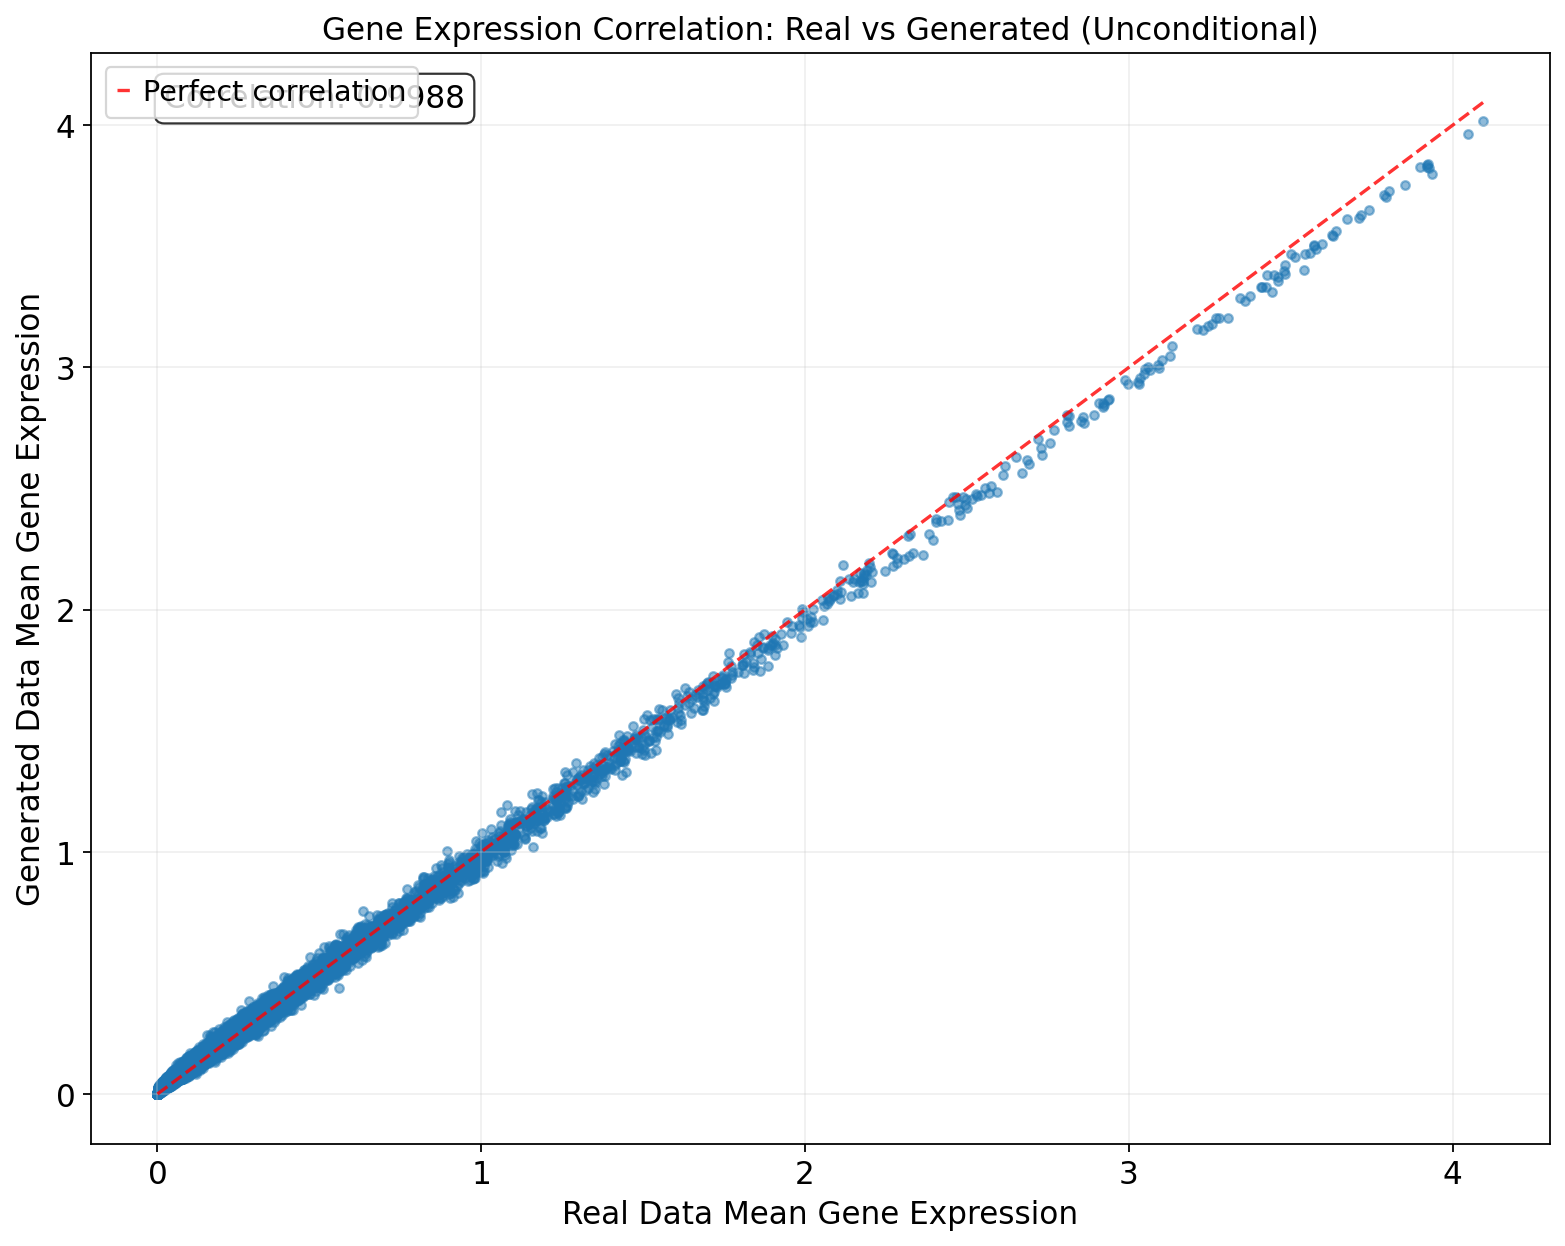

Unconditional generation correlation: 0.9988


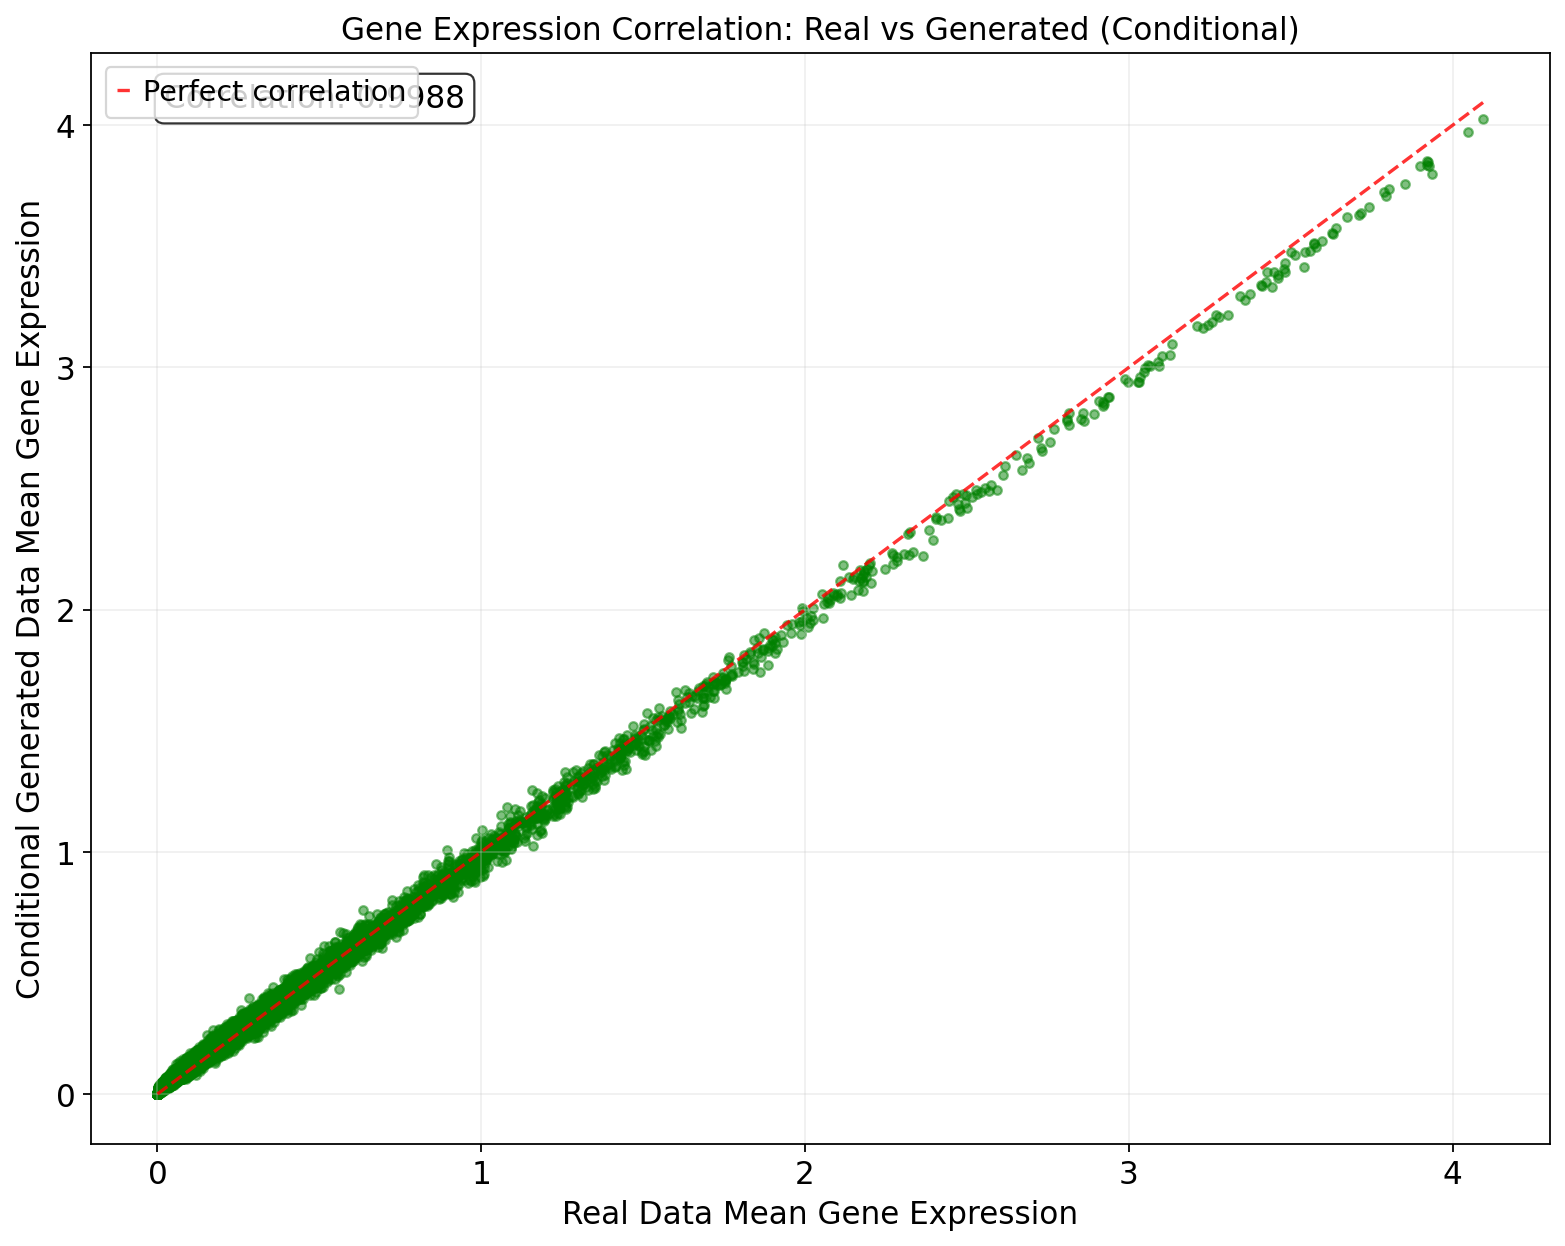

Conditional generation correlation: 0.9988


In [6]:
# Analyze gene expression correlation between real and generated data
if cell_gen is not None:
    # Calculate mean expression per gene
    real_gene_means = cell_data.mean(axis=0)
    gen_gene_means = cell_gen.mean(axis=0)
    
    # Plot correlation
    plt.figure(figsize=(10, 8))
    plt.scatter(real_gene_means, gen_gene_means, alpha=0.5, s=15)
    plt.xlabel('Real Data Mean Gene Expression')
    plt.ylabel('Generated Data Mean Gene Expression')
    plt.title('Gene Expression Correlation: Real vs Generated (Unconditional)')
    
    # Add diagonal line
    min_val = min(real_gene_means.min(), gen_gene_means.min())
    max_val = max(real_gene_means.max(), gen_gene_means.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.8, label='Perfect correlation')
    
    # Calculate correlation
    corr_coef = np.corrcoef(real_gene_means, gen_gene_means)[0, 1]
    plt.text(0.05, 0.95, f'Correlation: {corr_coef:.4f}', transform=plt.gca().transAxes, 
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"Unconditional generation correlation: {corr_coef:.4f}")

# Conditional correlation if available
if cell_gen_conditional is not None:
    plt.figure(figsize=(10, 8))
    
    cond_gene_means = cell_gen_conditional.mean(axis=0)
    plt.scatter(real_gene_means, cond_gene_means, alpha=0.5, s=15, color='green')
    plt.xlabel('Real Data Mean Gene Expression')
    plt.ylabel('Conditional Generated Data Mean Gene Expression')
    plt.title('Gene Expression Correlation: Real vs Generated (Conditional)')
    
    # Add diagonal line
    min_val = min(real_gene_means.min(), cond_gene_means.min())
    max_val = max(real_gene_means.max(), cond_gene_means.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.8, label='Perfect correlation')
    
    # Calculate correlation
    corr_coef_cond = np.corrcoef(real_gene_means, cond_gene_means)[0, 1]
    plt.text(0.05, 0.95, f'Correlation: {corr_coef_cond:.4f}', transform=plt.gca().transAxes,
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"Conditional generation correlation: {corr_coef_cond:.4f}")

## Prepare Combined Data for UMAP

In [7]:
# Prepare data for UMAP visualization
print("Preparing data for UMAP...")

# Choose which generated data to use (prefer conditional if available)
if cell_gen_conditional is not None:
    cell_gen_final = cell_gen_conditional
    gen_class_final = gen_class
    print("Using conditional generated data for UMAP")
elif cell_gen is not None:
    cell_gen_final = cell_gen
    gen_class_final = [f"gen_Cell" for i in range(cell_gen.shape[0])]
    print("Using unconditional generated data for UMAP")
else:
    print("No generated data available!")
    cell_gen_final = None

if cell_gen_final is not None:
    # Combine real and generated data
    all_data = np.concatenate((cell_data, cell_gen_final), axis=0)
    adata_combined = ad.AnnData(all_data, dtype=np.float32)
    
    print(f"Combined data shape: {adata_combined.shape}")
    
    # Create cell labels (real vs generated)
    cell_names = [f"Real_Cell" for i in range(cell_data.shape[0])] + \
                 [f"Generated_Cell" for i in range(cell_gen_final.shape[0])]
    adata_combined.obs['cell_origin'] = cell_names
    
    # Add cell type information if available
    if celltype is not None and cell_gen_conditional is not None:
        # For real cells, use actual cell types
        real_cell_types = celltype.values if hasattr(celltype, 'values') else celltype
        # For generated cells, use generated cell types
        all_cell_types = list(real_cell_types) + gen_class_final
        adata_combined.obs['celltype'] = all_cell_types
        print(f"Added cell type information: {len(set(all_cell_types))} unique types")
    else:
        print("Cell type information not available or incomplete")
    
    print("Data preparation completed!")
else:
    print("Cannot create UMAP without generated data")

Preparing data for UMAP...
Using conditional generated data for UMAP


Combined data shape: (7696, 27998)
Added cell type information: 16 unique types
Data preparation completed!


## UMAP Preprocessing and Computation

In [8]:
# Check for infinite values and data quality before UMAP preprocessing
if 'adata_combined' in locals():
    print("Checking data quality...")
    
    # Check for infinite values
    if hasattr(adata_combined.X, 'data'):
        # Sparse matrix
        data_array = np.array(adata_combined.X.data)
        n_inf = np.isinf(data_array).sum()
        n_nan = np.isnan(data_array).sum()
    else:
        # Dense matrix
        n_inf = np.isinf(adata_combined.X).sum()
        n_nan = np.isnan(adata_combined.X).sum()
    
    print(f"Infinite values: {n_inf}")
    print(f"NaN values: {n_nan}")
    
    if n_inf > 0 or n_nan > 0:
        print("Fixing infinite and NaN values...")
        
        # Handle infinite and NaN values
        if hasattr(adata_combined.X, 'data'):
            # Sparse matrix
            adata_combined.X.data[np.isinf(adata_combined.X.data)] = 0
            adata_combined.X.data[np.isnan(adata_combined.X.data)] = 0
        else:
            # Dense matrix
            adata_combined.X[np.isinf(adata_combined.X)] = 0
            adata_combined.X[np.isnan(adata_combined.X)] = 0
            
        print("Fixed infinite and NaN values")
    
    # Check data range
    try:
        if hasattr(adata_combined.X, 'data'):
            data_array = np.array(adata_combined.X.data)
            data_min = data_array.min()
            data_max = data_array.max()
        else:
            data_min = adata_combined.X.min()
            data_max = adata_combined.X.max()
        
        print(f"Data range: [{data_min:.4f}, {data_max:.4f}]")
    except Exception as e:
        print(f"Could not determine data range: {e}")
        # Try alternative approach
        try:
            data_min = adata_combined.X.min()
            data_max = adata_combined.X.max()
            print(f"Data range (alternative): [{data_min:.4f}, {data_max:.4f}]")
        except:
            print("Could not determine data range with any method")
    
    print(f"Data shape: {adata_combined.shape}")
    print("Data quality check completed!")

Checking data quality...


Infinite values: 0
NaN values: 0
Data range: [0.0000, 7.8640]
Data shape: (7696, 27998)
Data quality check completed!


In [9]:
if 'adata_combined' in locals():
    print("Preprocessing data for UMAP...")
    
    # Check data before highly variable genes detection
    print(f"Data shape before preprocessing: {adata_combined.shape}")
    print(f"Data type: {type(adata_combined.X)}")
    
    try:
        # Ensure we have a proper numpy array
        if not isinstance(adata_combined.X, np.ndarray):
            print("Converting to numpy array...")
            adata_combined.X = np.array(adata_combined.X)
        
        print(f"Data range: [{adata_combined.X.min():.4f}, {adata_combined.X.max():.4f}]")
        
        # The data is already log-normalized, so we proceed with feature selection
        print("Running highly variable genes detection...")
        sc.pp.highly_variable_genes(adata_combined, min_mean=0.0125, max_mean=3, min_disp=0.5)
        print(f"Found {sum(adata_combined.var.highly_variable)} highly variable genes")
        
        # Store raw data and filter
        adata_combined.raw = adata_combined
        adata_combined = adata_combined[:, adata_combined.var.highly_variable]
        
        print(f"Data after filtering: {adata_combined.shape}")
        
        # Scale data
        print("Scaling data...")
        sc.pp.scale(adata_combined, max_value=10)
        
        # PCA
        print("Running PCA...")
        sc.tl.pca(adata_combined, svd_solver='arpack')
        print("PCA completed!")
        
        # Neighbors and UMAP
        print("Computing neighbors...")
        sc.pp.neighbors(adata_combined, n_neighbors=15, n_pcs=40)
        
        print("Computing UMAP...")
        sc.tl.umap(adata_combined)
        
        print("UMAP computation completed!")
        
    except Exception as e:
        print(f"Error during preprocessing: {e}")
        print(f"Error type: {type(e)}")
        
        # Try alternative approach with more conservative parameters
        print("\nTrying alternative approach...")
        try:
            # Ensure proper numpy array
            adata_combined.X = np.array(adata_combined.X, dtype=np.float32)
            
            # Apply a small epsilon to avoid issues
            adata_combined.X = adata_combined.X + 1e-8
            
            print("Trying highly variable genes with alternative parameters...")
            sc.pp.highly_variable_genes(adata_combined, min_mean=0.1, max_mean=5, min_disp=0.3, n_top_genes=2000)
            print(f"Found {sum(adata_combined.var.highly_variable)} highly variable genes (alternative method)")
            
            # Continue with rest of preprocessing
            adata_combined.raw = adata_combined
            adata_combined = adata_combined[:, adata_combined.var.highly_variable]
            
            print(f"Data after filtering: {adata_combined.shape}")
            
            sc.pp.scale(adata_combined, max_value=10)
            sc.tl.pca(adata_combined, svd_solver='arpack')
            sc.pp.neighbors(adata_combined, n_neighbors=15, n_pcs=40)
            sc.tl.umap(adata_combined)
            
            print("UMAP computation completed with alternative method!")
            
        except Exception as e2:
            print(f"Alternative approach also failed: {e2}")
            print("Will proceed with manual gene selection...")

Preprocessing data for UMAP...
Data shape before preprocessing: (7696, 27998)
Data type: <class 'numpy.ndarray'>
Data range: [0.0000, 7.8640]
Running highly variable genes detection...
extracting highly variable genes


    finished (0:00:01)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
Found 8387 highly variable genes
Data after filtering: (7696, 8387)
Scaling data...
Running PCA...
computing PCA
    on highly variable genes
    with n_comps=50
    finished (0:00:19)
PCA completed!
Computing neighbors...
computing neighbors
    using 'X_pca' with n_pcs = 40
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:05)
Computing UMAP...
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:00:06)
UMAP computation completed!


In [ ]:
# # Manual highly variable gene selection as fallback
# if 'adata_combined' in locals():
#     print("\nUsing manual highly variable gene selection...")
    
#     try:
#         # Calculate gene statistics manually
#         print("Calculating gene statistics...")
        
#         # Calculate mean and variance for each gene
#         gene_means = np.mean(adata_combined.X, axis=0)
#         gene_vars = np.var(adata_combined.X, axis=0)
        
#         # Avoid division by zero and log of zero
#         gene_means_safe = np.maximum(gene_means, 1e-8)
#         gene_vars_safe = np.maximum(gene_vars, 1e-8)
        
#         # Calculate coefficient of variation (CV)
#         gene_cv = np.sqrt(gene_vars_safe) / gene_means_safe
        
#         # Select top variable genes based on CV
#         n_top_genes = 2000
#         top_gene_indices = np.argsort(gene_cv)[-n_top_genes:]
        
#         # Create highly variable mask
#         highly_variable_mask = np.zeros(adata_combined.shape[1], dtype=bool)
#         highly_variable_mask[top_gene_indices] = True
        
#         # Add to adata object
#         adata_combined.var['highly_variable'] = highly_variable_mask
#         adata_combined.var['means'] = gene_means
#         adata_combined.var['dispersions'] = gene_vars
        
#         print(f"Selected {n_top_genes} highly variable genes manually")
        
#         # Store raw data and filter
#         adata_combined.raw = adata_combined
#         adata_combined = adata_combined[:, adata_combined.var.highly_variable]
        
#         print(f"Data after filtering: {adata_combined.shape}")
        
#         # Scale data
#         print("Scaling data...")
#         sc.pp.scale(adata_combined, max_value=10)
        
#         # PCA
#         print("Running PCA...")
#         sc.tl.pca(adata_combined, svd_solver='arpack')
#         print("PCA completed!")
        
#         # Neighbors and UMAP
#         print("Computing neighbors...")
#         sc.pp.neighbors(adata_combined, n_neighbors=15, n_pcs=40)
        
#         print("Computing UMAP...")
#         sc.tl.umap(adata_combined)
        
#         print("UMAP computation completed with manual gene selection!")
        
#     except Exception as e:
#         print(f"Manual gene selection also failed: {e}")
#         print("This might indicate a deeper issue with the data preparation")
        
#         # Let's try a very simple approach - just use all genes
#         print("\nTrying with all genes (no filtering)...")
#         try:
#             # Clone the original data
#             adata_simple = adata_combined.copy()
            
#             # Just scale and run PCA/UMAP without gene filtering
#             sc.pp.scale(adata_simple, max_value=10)
#             sc.tl.pca(adata_simple, svd_solver='arpack', n_comps=50)
#             sc.pp.neighbors(adata_simple, n_neighbors=15, n_pcs=40)
#             sc.tl.umap(adata_simple)
            
#             # Replace the original with the working version
#             adata_combined = adata_simple
#             print("UMAP completed with all genes (no filtering)!")
            
#         except Exception as e3:
#             print(f"Even simple approach failed: {e3}")
#             print("There may be a fundamental issue with the data or environment")


Using manual highly variable gene selection...
Calculating gene statistics...
Selected 2000 highly variable genes manually
Data after filtering: (7696, 2000)
Scaling data...


Running PCA...
computing PCA
    on highly variable genes
    with n_comps=50
    finished (0:00:03)
PCA completed!
Computing neighbors...
computing neighbors
    using 'X_pca' with n_pcs = 40
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:01)
Computing UMAP...
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:00:06)
UMAP computation completed with manual gene selection!


## UMAP Visualization: Real vs Generated

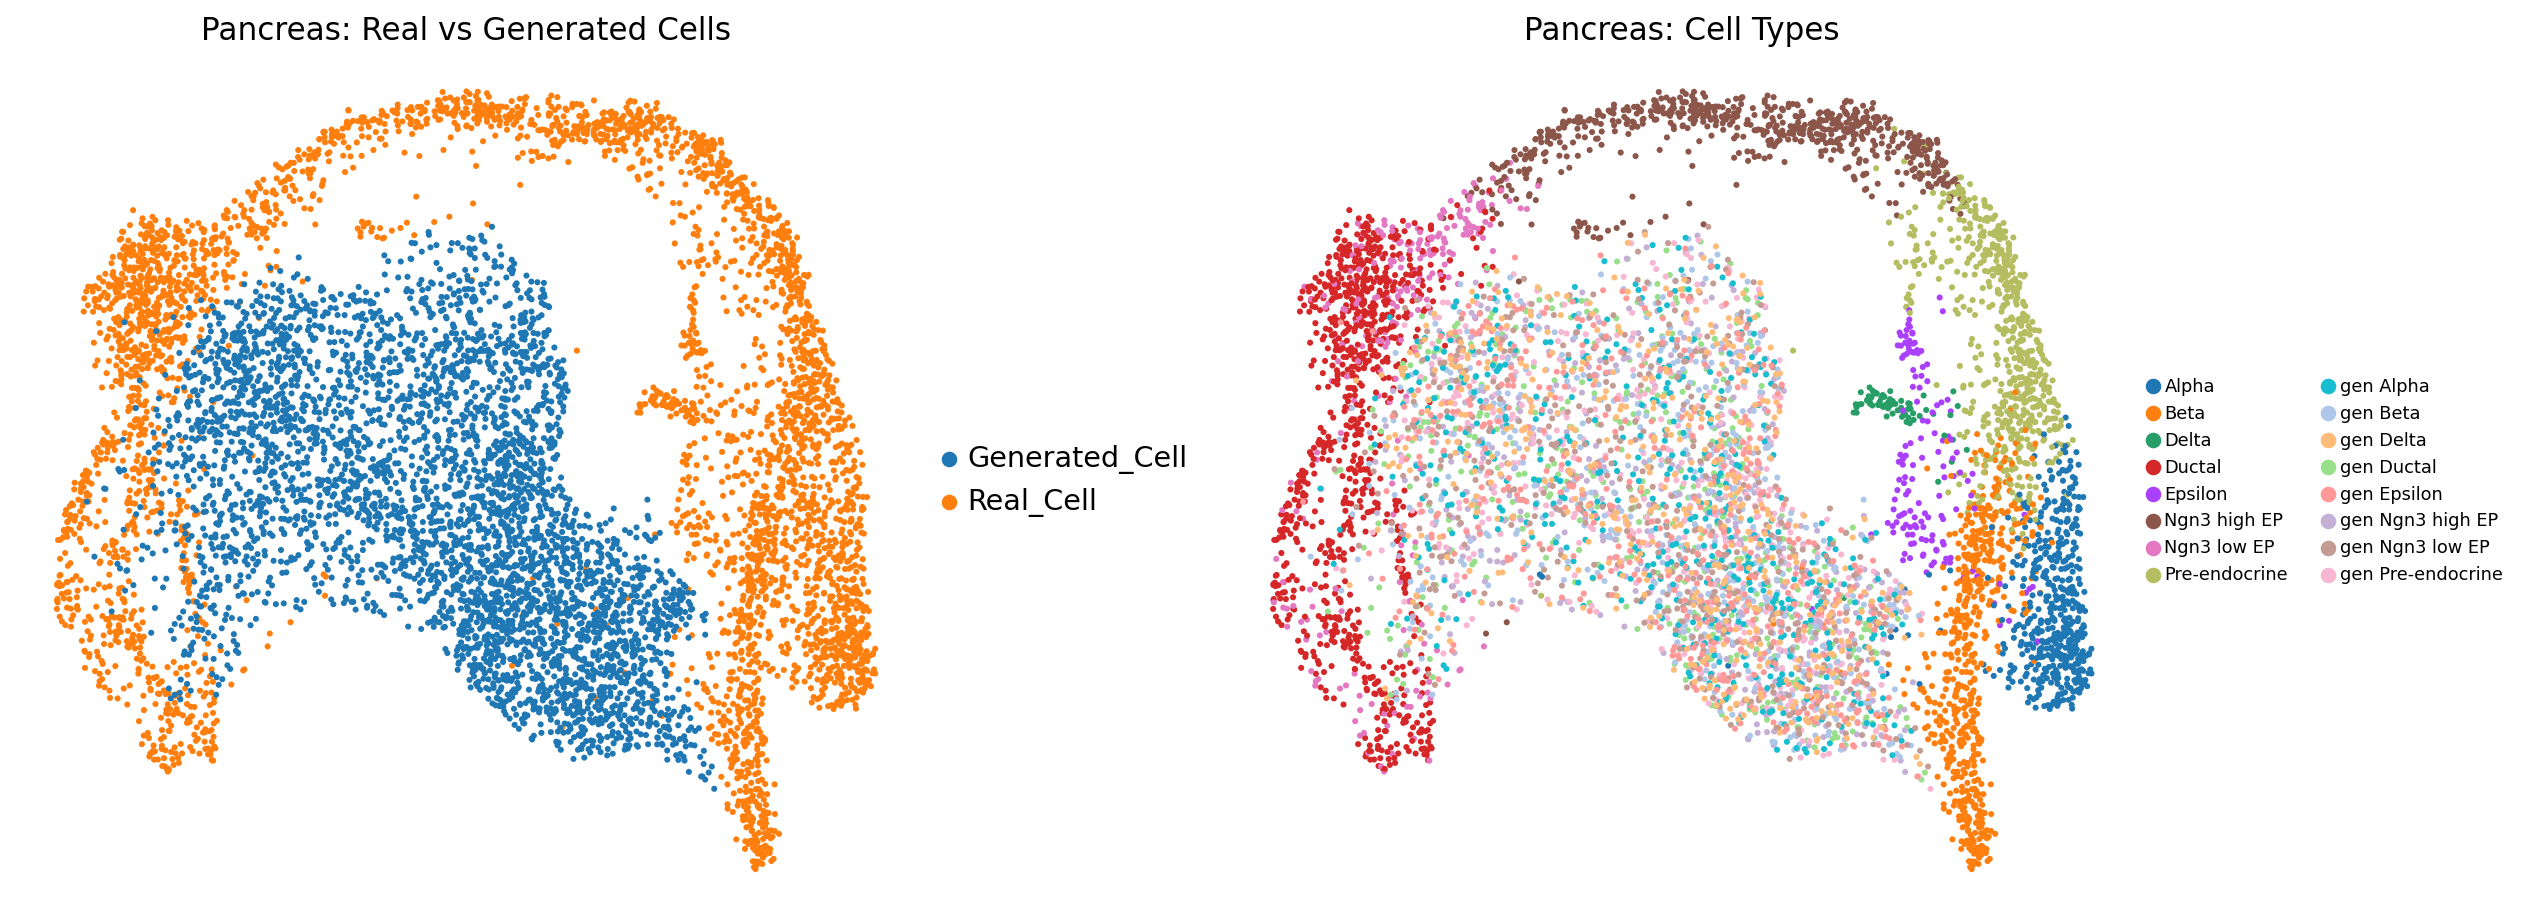

UMAP visualization completed!


In [10]:
if 'adata_combined' in locals():
    # Plot UMAP colored by cell origin (real vs generated)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Plot 1: Real vs Generated
    sc.pl.umap(adata_combined, color="cell_origin", size=30, 
               title='Pancreas: Real vs Generated Cells', 
               ax=axes[0], show=False, frameon=False)
    
    # Plot 2: Cell types (if available)
    if 'celltype' in adata_combined.obs.columns:
        sc.pl.umap(adata_combined, color="celltype", size=30, 
                   title='Pancreas: Cell Types', 
                   ax=axes[1], show=False, frameon=False, 
                   legend_loc='right margin', legend_fontsize=8)
    else:
        # If no cell types, show another view
        sc.pl.umap(adata_combined, color="cell_origin", size=30, 
                   title='Pancreas: Real vs Generated (Alternative View)', 
                   ax=axes[1], show=False, frameon=False)
    
    plt.tight_layout()
    plt.show()
    
    print("UMAP visualization completed!")

## Individual Cell Type Comparisons

Creating individual cell type comparisons...


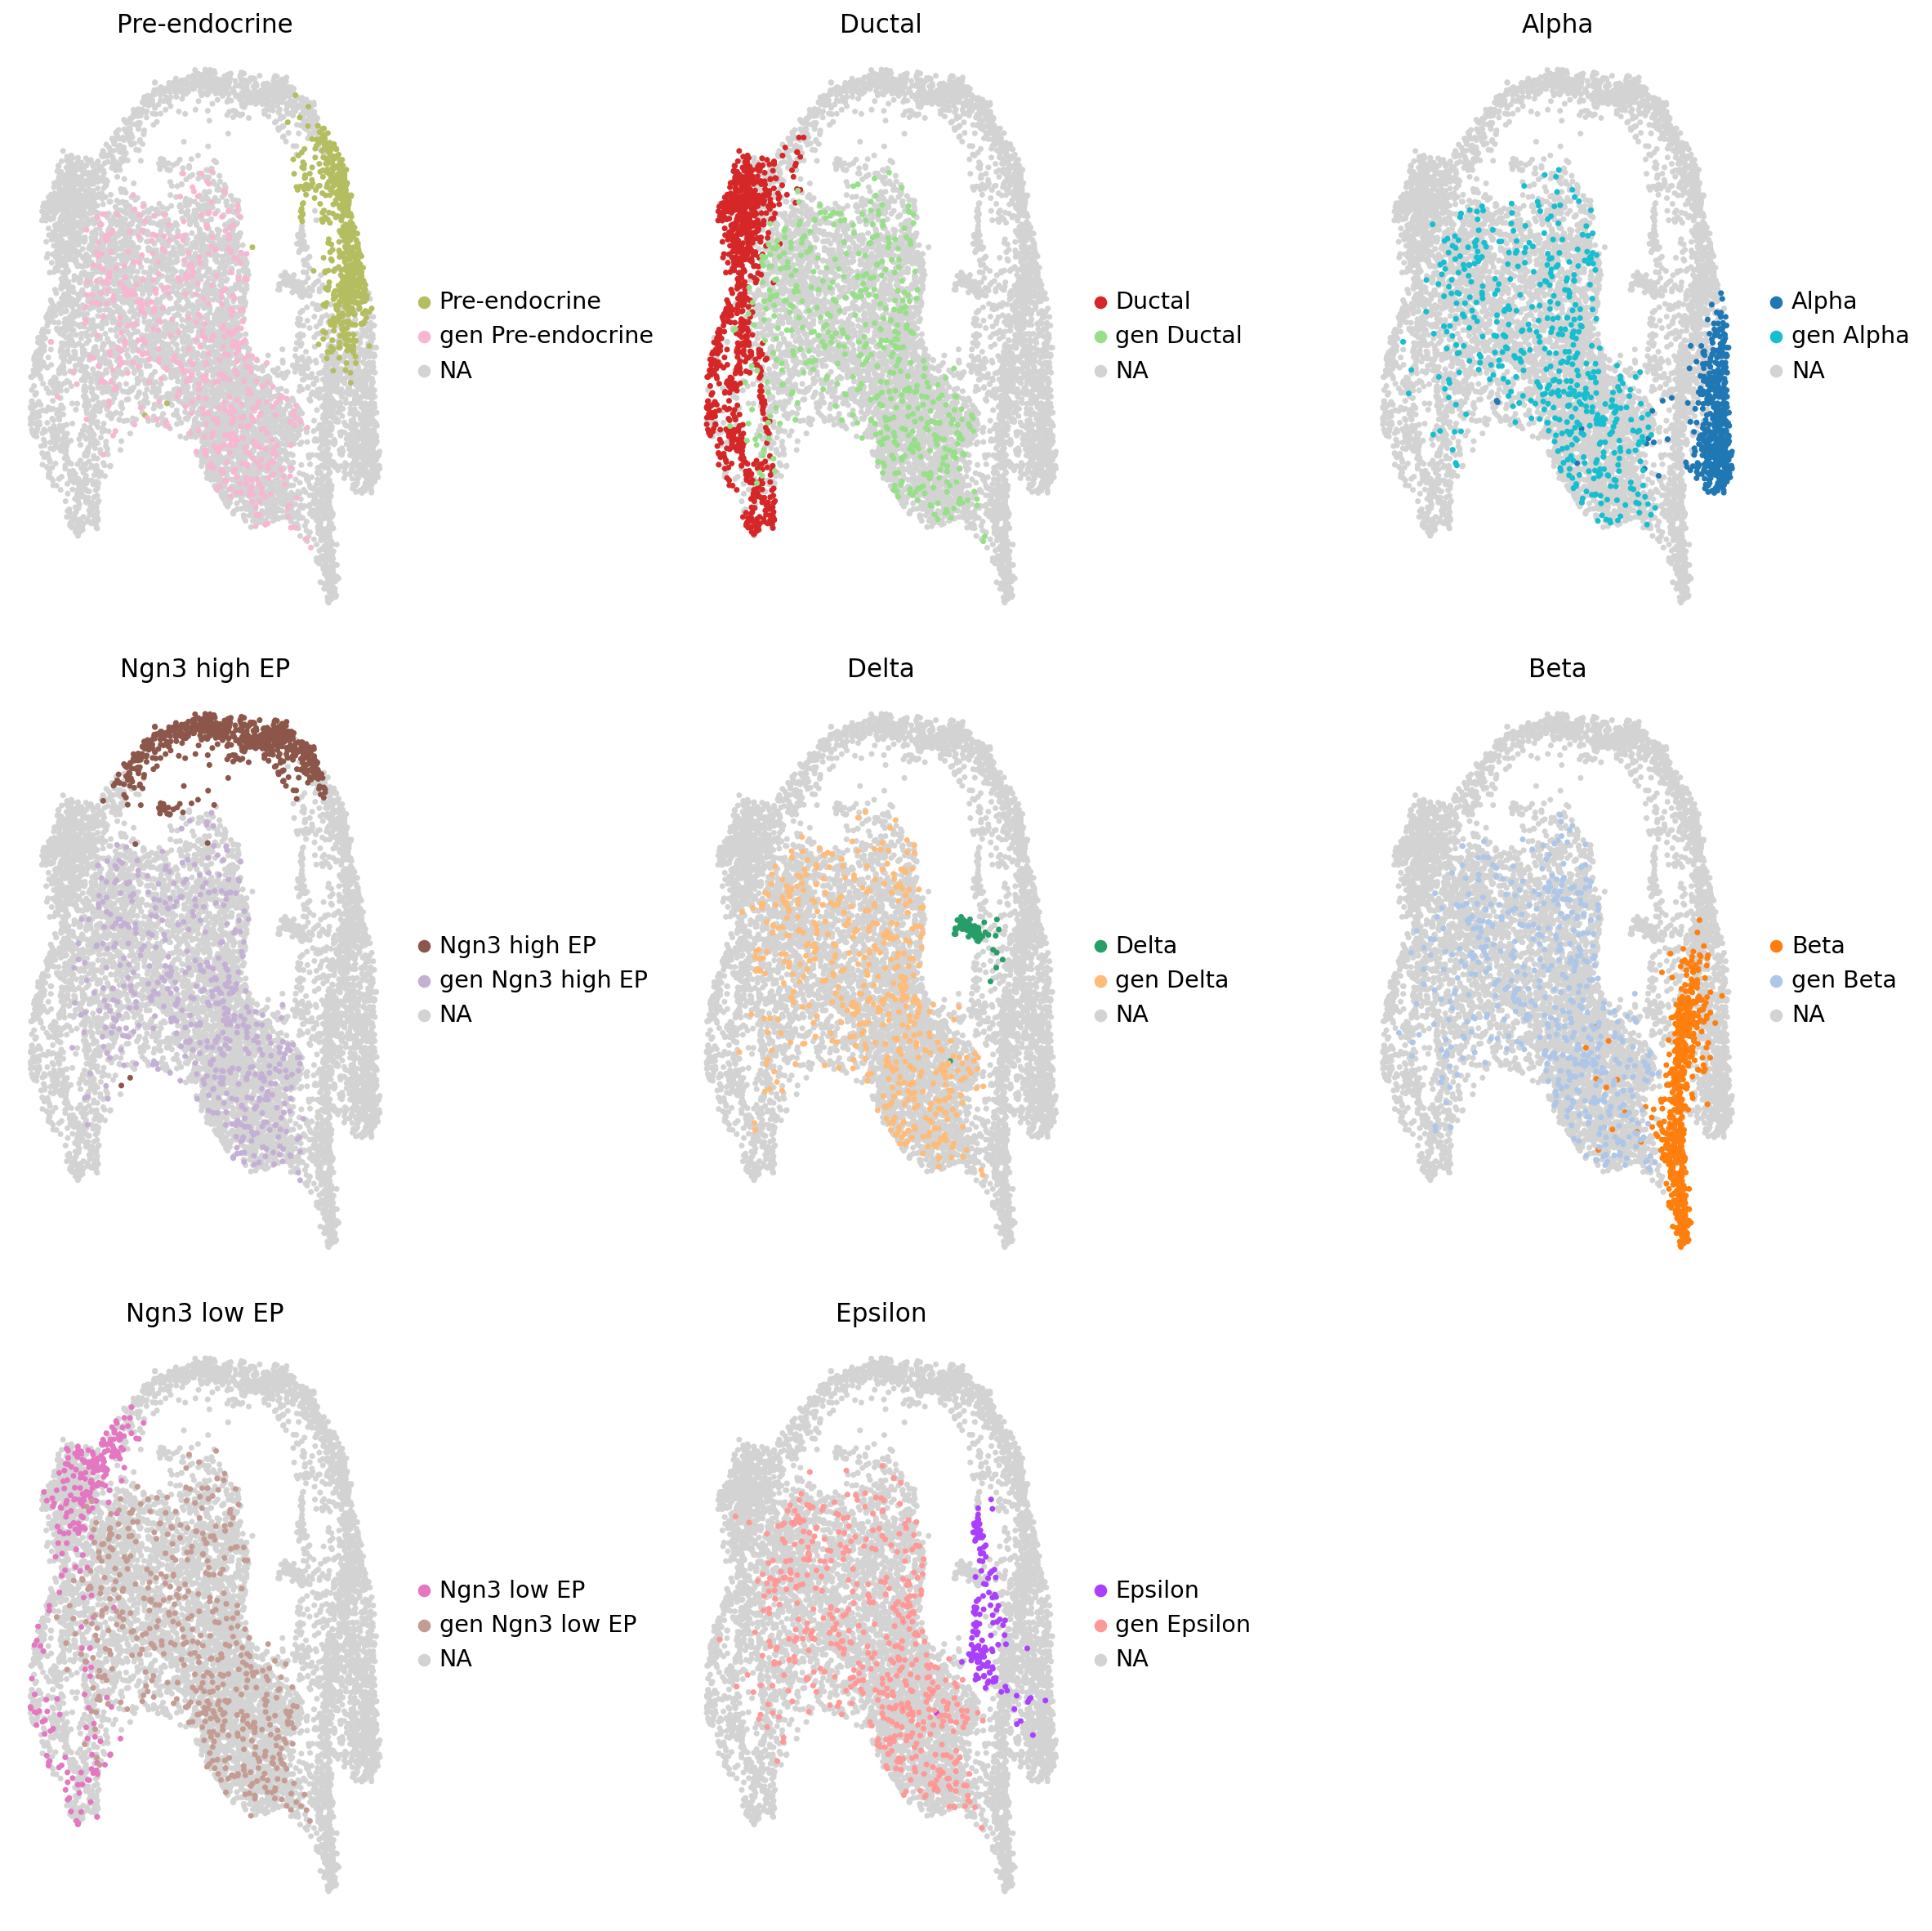

Individual plots created for 8 cell types


In [11]:
# Individual cell type comparisons for pancreas
if 'adata_combined' in locals() and 'celltype' in adata_combined.obs.columns and cell_gen_conditional is not None:
    print("Creating individual cell type comparisons...")
    
    # Get unique cell types from real data
    real_cell_types = [ct for ct in adata_combined.obs['celltype'].unique() if not ct.startswith('gen ')]
    
    # Create subplots
    n_types = len(real_cell_types)
    n_cols = 3
    n_rows = (n_types + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    
    for i, cell_type in enumerate(real_cell_types):
        row, col = i // n_cols, i % n_cols
        ax = axes[row, col]
        
        # Plot this cell type
        groups_to_show = [cell_type]
        if f'gen {cell_type}' in adata_combined.obs['celltype'].unique():
            groups_to_show.append(f'gen {cell_type}')
        
        try:
            sc.pl.umap(adata_combined, color="celltype", groups=groups_to_show, 
                      size=40, ax=ax, show=False, frameon=False, title=f'{cell_type}')
        except Exception as e:
            print(f"Warning: Could not plot {cell_type}: {e}")
            ax.text(0.5, 0.5, f'No data for\n{cell_type}', ha='center', va='center', 
                   transform=ax.transAxes)
    
    # Hide empty subplots
    for i in range(n_types, n_rows * n_cols):
        row, col = i // n_cols, i % n_cols
        axes[row, col].set_visible(False)
    
    plt.tight_layout()
    plt.show()
    
    print(f"Individual plots created for {len(real_cell_types)} cell types")
else:
    print("Cell type information not available for individual comparisons")
    if 'adata_combined' in locals():
        print("Available obs columns:", list(adata_combined.obs.columns))

## Summary and Results

In [12]:
print("=== PANCREAS DATASET UMAP ANALYSIS SUMMARY ===")
print(f"Real data shape: {cell_data.shape}")
if cell_gen is not None:
    print(f"Unconditional generated data shape: {cell_gen.shape}")
if cell_gen_conditional is not None:
    print(f"Conditional generated data shape: {cell_gen_conditional.shape}")
    print(f"Generated cell types: {set([ct.replace('gen ', '') for ct in gen_class])}")

if celltype is not None:
    print(f"Real cell types: {list(celltype.unique())}")

if 'corr_coef' in locals():
    print(f"Unconditional correlation: {corr_coef:.4f}")
if 'corr_coef_cond' in locals():
    print(f"Conditional correlation: {corr_coef_cond:.4f}")

print("\nUMAP visualizations have been created showing:")
print("1. Real vs Generated cells comparison")
print("2. Cell type distribution")
if cell_gen_conditional is not None:
    print("3. Individual cell type comparisons")

print("\nAnalysis completed!")

=== PANCREAS DATASET UMAP ANALYSIS SUMMARY ===
Real data shape: (3696, 27998)
Unconditional generated data shape: (3000, 27998)
Conditional generated data shape: (4000, 27998)
Generated cell types: {'Ngn3 low EP', 'Ngn3 high EP', 'Epsilon', 'Pre-endocrine', 'Beta', 'Ductal', 'Delta', 'Alpha'}
Real cell types: ['Pre-endocrine', 'Ductal', 'Alpha', 'Ngn3 high EP', 'Delta', 'Beta', 'Ngn3 low EP', 'Epsilon']
Unconditional correlation: 0.9988
Conditional correlation: 0.9988

UMAP visualizations have been created showing:
1. Real vs Generated cells comparison
2. Cell type distribution
3. Individual cell type comparisons

Analysis completed!
